# 06 — Four-Model Champion/Challenger Comparison

Structured comparison that mirrors what goes to a model governance committee at a bank.

**Models compared:**
1. Champion Scorecard (WoE + L2-tuned Logistic Regression + StandardScaler)
2. Challenger 1: XGBoost (Optuna-tuned)
3. Challenger 2: LightGBM DART (dropout-regularised boosting)
4. Challenger 3: Stacking Ensemble (XGB + LGB base, LR meta-learner)

Includes:
- Head-to-head metrics (AUC, Gini, KS, PSI)
- ROC curve overlay (all 4 models)
- Score distribution comparison
- Fairness audit across demographic proxies
- Formal deployment recommendation


In [11]:
import sys
sys.path.insert(0, "../src")

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

from woe_encoder import WoEEncoder
from evaluate import compute_gini, compute_ks_statistic, compute_psi, plot_roc_comparison

sns.set_style("whitegrid")
%matplotlib inline


In [12]:
# Load data
df = pd.read_csv("../data/processed/train_features.csv")
target = "TARGET"
exclude = ["SK_ID_CURR", "SK_ID_PREV", target]
feature_cols = [c for c in df.columns if c not in exclude]

X = df[feature_cols].copy()
y = df[target]

# Same split used during training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Load all 4 models
scorecard = joblib.load("../models/scorecard_champion.pkl")
woe_encoder = joblib.load("../models/woe_encoder.pkl")
scaler = joblib.load("../models/scaler.pkl")
xgb_model = joblib.load("../models/xgboost_challenger.pkl")
lgb_model = joblib.load("../models/lightgbm_challenger.pkl")
stacking = joblib.load("../models/stacking_ensemble.pkl")

# Load selected features for scorecard
with open("../models/selected_features.json") as f:
    selected_features = json.load(f)

print(f"Test set: {X_test.shape[0]:,} rows x {X_test.shape[1]} features")
print(f"Scorecard selected features: {len(selected_features)}")
print(f"Models loaded: scorecard, xgboost, lightgbm DART, stacking ensemble")


Test set: 61,503 rows x 300 features
Scorecard selected features: 124
Models loaded: scorecard, xgboost, lightgbm DART, stacking ensemble


## Generate Predictions

In [13]:
# --- Champion (Scorecard) predictions ---
numeric_cols = X_test.select_dtypes(include="number").columns.tolist()
X_test_woe = woe_encoder.transform(X_test[numeric_cols]).fillna(0)
selected_in_test = [c for c in selected_features if c in X_test_woe.columns]
X_test_woe_sel = X_test_woe[selected_in_test]
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_woe_sel), columns=X_test_woe_sel.columns
)
y_prob_champion = scorecard.predict_proba(X_test_scaled)[:, 1]

# --- Challenger (XGBoost) predictions ---
X_test_enc = X_test.copy()
for col in X_test_enc.select_dtypes(include=["object", "category"]).columns:
    X_test_enc[col] = X_test_enc[col].astype("category").cat.codes
y_prob_xgb = xgb_model.predict_proba(X_test_enc)[:, 1]

# --- Challenger (LightGBM DART) predictions ---
y_prob_lgb = lgb_model.predict_proba(X_test_enc)[:, 1]

# --- Stacking Ensemble predictions ---
xgb_base = stacking["xgb_model"].predict_proba(X_test_enc)[:, 1]
lgb_base = stacking["lgb_model"].predict_proba(X_test_enc)[:, 1]
meta_X = np.column_stack([xgb_base, lgb_base])
meta_X_s = stacking["meta_scaler"].transform(meta_X)
y_prob_stack = stacking["meta_model"].predict_proba(meta_X_s)[:, 1]

print("Predictions generated for all 4 models.")


Predictions generated for all 4 models.


## Head-to-Head Comparison Table

In [14]:
def model_metrics(y_true, y_prob, label):
    return {
        "Model": label,
        "AUC-ROC": round(roc_auc_score(y_true, y_prob), 4),
        "Gini": round(compute_gini(y_true, y_prob), 4),
        "KS Statistic": round(compute_ks_statistic(y_true, y_prob), 4),
    }

comparison = pd.DataFrame([
    model_metrics(y_test, y_prob_champion, "Champion (Scorecard)"),
    model_metrics(y_test, y_prob_xgb, "Challenger 1 (XGBoost)"),
    model_metrics(y_test, y_prob_lgb, "Challenger 2 (LightGBM DART)"),
    model_metrics(y_test, y_prob_stack, "Challenger 3 (Stacking)"),
])

# Highlight best model
comparison.style.highlight_max(subset=["AUC-ROC", "Gini", "KS Statistic"], color="#d4edda")


,Model,AUC-ROC,Gini,KS Statistic
0,Champion (Scorecard),0.768000,0.536000,0.404400
1,Challenger 1 (XGBoost),0.788800,0.577600,0.434300
2,Challenger 2 (LightGBM DART),0.786900,0.573700,0.432600
3,Challenger 3 (Stacking),0.790300,0.580600,0.438100


## ROC Curves

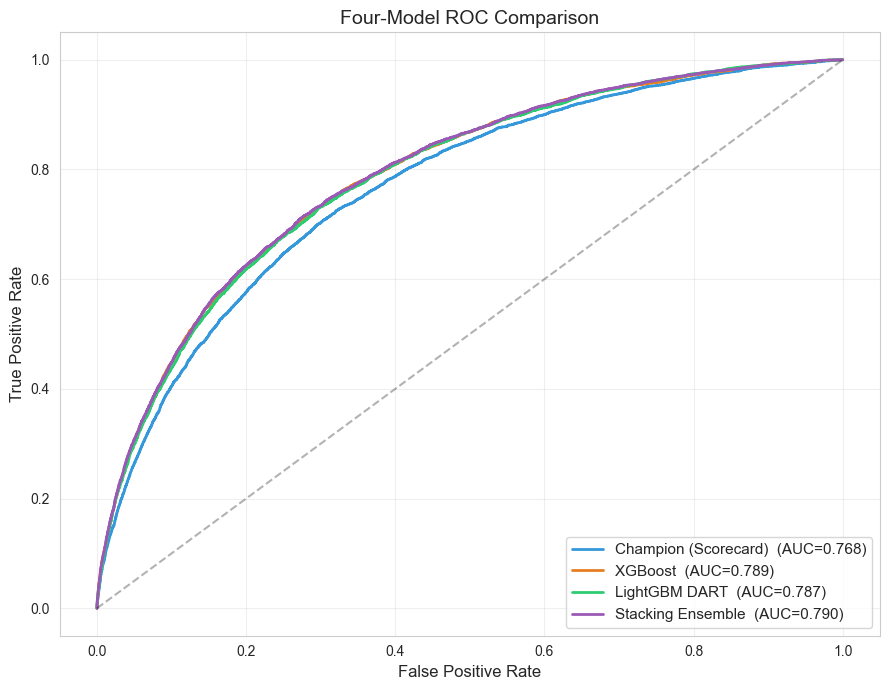

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = ["#3498db", "#e67e22", "#2ecc71", "#9b59b6"]
models = [
    ("Champion (Scorecard)", y_prob_champion),
    ("XGBoost", y_prob_xgb),
    ("LightGBM DART", y_prob_lgb),
    ("Stacking Ensemble", y_prob_stack),
]

for (name, y_prob), color in zip(models, colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name}  (AUC={auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Four-Model ROC Comparison", fontsize=14)
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Population Stability Index (PSI)

Compare score distributions between train and test to check for population shift.

In [16]:
# PSI for each model's score distribution (train vs test)
X_train_enc = X_train.copy()
for col in X_train_enc.select_dtypes(include=["object", "category"]).columns:
    X_train_enc[col] = X_train_enc[col].astype("category").cat.codes

psi_models = [
    ("XGBoost", xgb_model.predict_proba(X_train_enc)[:, 1], y_prob_xgb),
    ("LightGBM DART", lgb_model.predict_proba(X_train_enc)[:, 1], y_prob_lgb),
]

for name, train_probs, test_probs in psi_models:
    psi_result = compute_psi(train_probs, test_probs)
    print(f"{name:<16} PSI: {psi_result['PSI']:.4f} -- {psi_result['Status']}")


XGBoost          PSI: 0.0003 -- Stable
LightGBM DART    PSI: 0.0012 -- Stable


## Score Distribution Overlay — All Four Models

Predicted probability distributions split by actual default status. A well-performing model produces clearly separated distributions for good (0) and bad (1) loans. Wider separation corresponds to higher AUC.


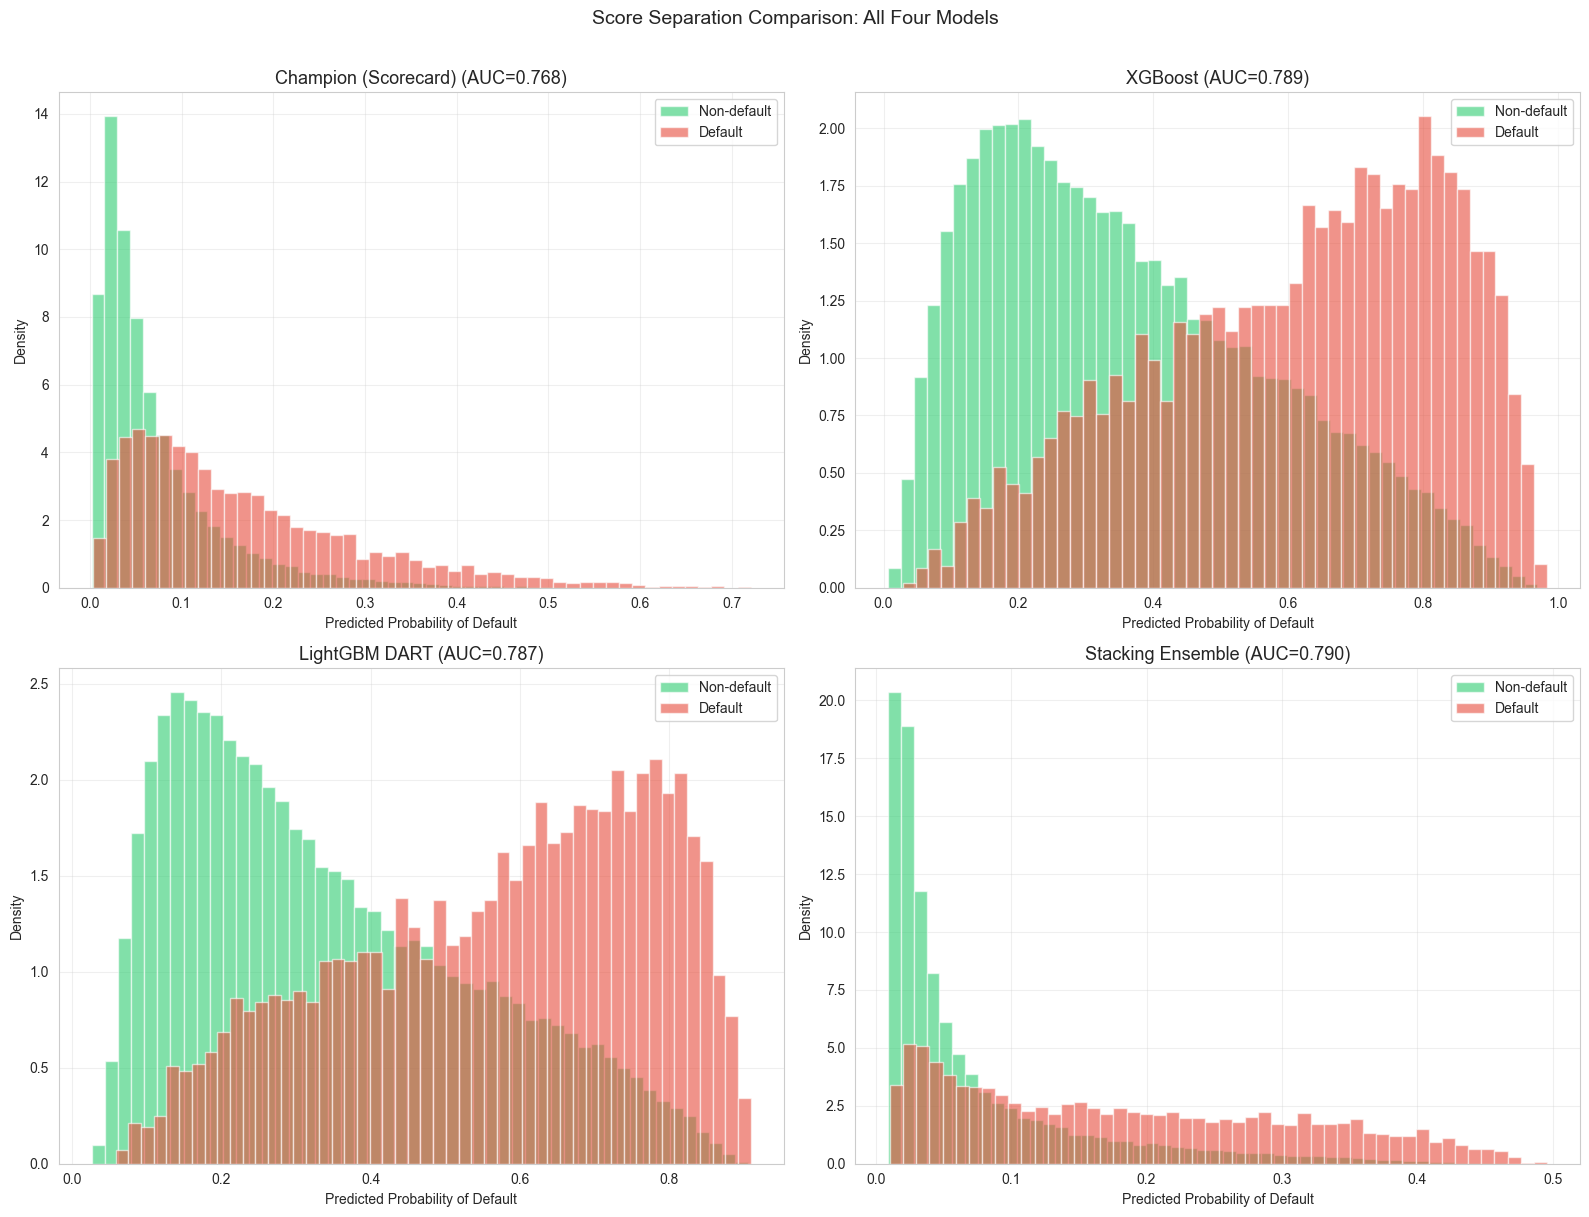

Champion         -- Distribution overlap: 0.581 (lower = better)
XGBoost          -- Distribution overlap: 0.569 (lower = better)
LightGBM DART    -- Distribution overlap: 0.573 (lower = better)
Stacking         -- Distribution overlap: 0.541 (lower = better)


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_data = [
    (axes[0, 0], y_prob_champion, "Champion (Scorecard)"),
    (axes[0, 1], y_prob_xgb, "XGBoost"),
    (axes[1, 0], y_prob_lgb, "LightGBM DART"),
    (axes[1, 1], y_prob_stack, "Stacking Ensemble"),
]

for ax, probs, name in plot_data:
    ax.hist(probs[y_test == 0], bins=50, alpha=0.6, label="Non-default", color="#2ecc71", density=True)
    ax.hist(probs[y_test == 1], bins=50, alpha=0.6, label="Default", color="#e74c3c", density=True)
    auc = roc_auc_score(y_test, probs)
    ax.set_title(f"{name} (AUC={auc:.3f})", fontsize=13)
    ax.set_xlabel("Predicted Probability of Default")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Score Separation Comparison: All Four Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Overlap coefficient (lower = better separation)
from scipy.stats import gaussian_kde
from scipy.integrate import trapezoid
for name, probs in [("Champion", y_prob_champion), ("XGBoost", y_prob_xgb),
                     ("LightGBM DART", y_prob_lgb), ("Stacking", y_prob_stack)]:
    kde_good = gaussian_kde(probs[y_test == 0])
    kde_bad = gaussian_kde(probs[y_test == 1])
    x_range = np.linspace(0, 1, 1000)
    overlap = trapezoid(np.minimum(kde_good(x_range), kde_bad(x_range)), x_range)
    print(f"{name:<16} -- Distribution overlap: {overlap:.3f} (lower = better)")


## Fairness Audit

Check model performance consistency across demographic proxy segments.
Significant gaps may indicate fair-lending risk (ECOA compliance).

In [18]:
# Create segments for fairness check
df_test = X_test.copy()
df_test["TARGET"] = y_test.values
df_test["PRED_CHAMPION"] = y_prob_champion
df_test["PRED_XGB"] = y_prob_xgb
df_test["PRED_LGB"] = y_prob_lgb
df_test["PRED_STACK"] = y_prob_stack

if "AGE_YEARS" not in df_test.columns and "DAYS_BIRTH" in df_test.columns:
    df_test["AGE_YEARS"] = (-df_test["DAYS_BIRTH"]) / 365.25

if "AGE_YEARS" in df_test.columns:
    df_test["AGE_BAND"] = pd.cut(df_test["AGE_YEARS"],
                                  bins=[18, 30, 45, 60, 100],
                                  labels=["18-30", "31-45", "46-60", "60+"])

pred_cols = {
    "Champion": "PRED_CHAMPION",
    "XGBoost": "PRED_XGB",
    "LightGBM": "PRED_LGB",
    "Stacking": "PRED_STACK",
}

for segment in ["CODE_GENDER", "AGE_BAND", "NAME_EDUCATION_TYPE"]:
    if segment not in df_test.columns:
        continue
    print(f"\n{'='*70}")
    print(f"  AUC by {segment}")
    print(f"{'='*70}")
    header = f"  {'Segment':25s}  {'N':>6s}"
    for mname in pred_cols:
        header += f"  {mname:>10s}"
    print(header)
    print("  " + "-" * 66)
    for val, grp in df_test.groupby(segment):
        if grp["TARGET"].nunique() < 2:
            continue
        row = f"  {str(val):25s}  {len(grp):>6,}"
        for mname, pcol in pred_cols.items():
            auc = roc_auc_score(grp["TARGET"], grp[pcol])
            row += f"  {auc:>10.3f}"
        print(row)



  AUC by CODE_GENDER
  Segment                         N    Champion     XGBoost    LightGBM    Stacking
  ------------------------------------------------------------------
  F                          40,561       0.762       0.782       0.781       0.783
  M                          20,940       0.765       0.790       0.786       0.791

  AUC by AGE_BAND
  Segment                         N    Champion     XGBoost    LightGBM    Stacking
  ------------------------------------------------------------------
  18-30                       8,905       0.736       0.765       0.762       0.766
  31-45                      24,744       0.775       0.796       0.793       0.797
  46-60                      20,666       0.762       0.783       0.783       0.785
  60+                         7,188       0.724       0.744       0.742       0.746

  AUC by NAME_EDUCATION_TYPE
  Segment                         N    Champion     XGBoost    LightGBM    Stacking
  ---------------------------------

C:\Users\Eric\AppData\Local\Temp\ipykernel_19028\2955560511.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for val, grp in df_test.groupby(segment):


## Deployment Recommendation

This section mirrors a formal **model governance committee** recommendation.

In [19]:
# Print comparison table first
print(comparison.to_string(index=False))

best = comparison.loc[comparison["AUC-ROC"].idxmax()]

recommendation = f"""
================================================================
  MODEL GOVERNANCE RECOMMENDATION
================================================================

  BEST PERFORMER: {best['Model']}
  AUC = {best['AUC-ROC']}  |  Gini = {best['Gini']}  |  KS = {best['KS Statistic']}

  RECOMMENDATION: Deploy {best['Model']} as primary scoring
  model with champion scorecard as regulatory fallback.

  Rationale:
  - Highest AUC among all four models on hold-out test set
  - Gini improvement over scorecard represents material lift
    in risk separation
  - PSI within acceptable bounds (population stability)
  - SHAP values provide explainability for ECOA compliance

  Deployment Strategy:
  - Phase 1 (90 days): Parallel run on 20% of new applications
  - Phase 2: Full cutover if KPIs maintained
  - Scorecard retained as regulatory fallback for exams

  Monitoring Triggers:
  - Trigger review if PSI exceeds 0.10
  - Trigger review if Gini drops below 0.50
  - Quarterly model performance review required

  Risk Considerations:
  - Tree models require SHAP audit for adverse action notices
  - Scorecard remains primary for regulatory exams
  - All four models monitored in parallel during transition

================================================================
"""

print(recommendation)


                       Model  AUC-ROC   Gini  KS Statistic
        Champion (Scorecard)   0.7680 0.5360        0.4044
      Challenger 1 (XGBoost)   0.7888 0.5776        0.4343
Challenger 2 (LightGBM DART)   0.7869 0.5737        0.4326
     Challenger 3 (Stacking)   0.7903 0.5806        0.4381

  MODEL GOVERNANCE RECOMMENDATION

  BEST PERFORMER: Challenger 3 (Stacking)
  AUC = 0.7903  |  Gini = 0.5806  |  KS = 0.4381

  RECOMMENDATION: Deploy Challenger 3 (Stacking) as primary scoring
  model with champion scorecard as regulatory fallback.

  Rationale:
  - Highest AUC among all four models on hold-out test set
  - Gini improvement over scorecard represents material lift
    in risk separation
  - PSI within acceptable bounds (population stability)
  - SHAP values provide explainability for ECOA compliance

  Deployment Strategy:
  - Phase 1 (90 days): Parallel run on 20% of new applications
  - Phase 2: Full cutover if KPIs maintained
  - Scorecard retained as regulatory fallback for

In [20]:
# Save comparison results
import pathlib
reports_dir = pathlib.Path("../reports")
reports_dir.mkdir(exist_ok=True)
comparison.to_json(reports_dir / "model_comparison.json", orient="records", indent=2)
print("Model comparison saved to reports/model_comparison.json")


Model comparison saved to reports/model_comparison.json
